<a href="https://githubtocolab.com/tannialhernandez/topicosAvanzadosAnalitica/blob/main/E11-Patent CitationNetwork/E11_PatentCitationNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Patent Citation Network

U.S. patent dataset is maintained by the [National Bureau of Economic Research](http://www.nber.org/). The data set spans 37 years (January 1, 1963 to December 30, 1999), and includes all the utility patents granted during that period, totaling 3,923,922 patents. The citation graph includes all citations made by patents granted between 1975 and 1999, totaling 16,522,438 citations. For the patents dataset there are 1,803,511 nodes for which we have no information about their citations (we only have the in-links).

The data was originally released by [NBER](http://www.nber.org/patents/). The dataset can be found at this link: [Stanford Patent Citation Network](https://snap.stanford.edu/data/cit-Patents.html)

In [1]:
!pip install -q node2vec
!pip install -qI gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 14.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 94.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 7.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into acco

## Import Packages

In [1]:
import torch
import pandas as pd
import numpy as np
import cupy as cp
import networkx as nx
import random
import matplotlib.pyplot as plt
from node2vec import Node2Vec
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms import approximation
from random import randint

%matplotlib inline


torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


## Import data

In [3]:
patent = pd.read_csv(
    "http://snap.stanford.edu/data/cit-Patents.txt.gz",
    compression="gzip",
    sep="\t",
    names=["start_node", "end_node"],
    skiprows=5
)

In [4]:
patent.head()

,start_node,end_node
0,3858241,1324234
1,3858241,3398406
2,3858241,3557384
3,3858241,3634889
4,3858242,1515701


In [5]:
patent.shape

(16518947, 2)

## Build Recommendation System

build a recommendation system based on Node2Vec with the patent information, remember to do a descriptive analysis and apply visualizations.

Also, remember that when making a recommendation about which patent should be associated with another, make a visualization of the recommendation.

In [6]:
G = nx.from_pandas_edgelist(patent, "start_node", "end_node", create_using=nx.DiGraph())

In [7]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 3774767
Number of edges: 16518947


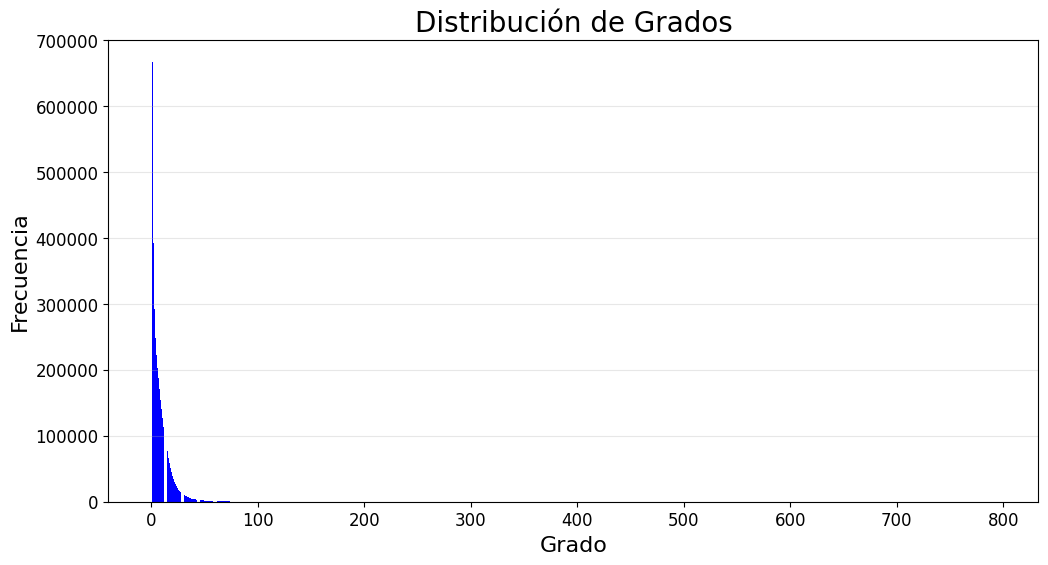

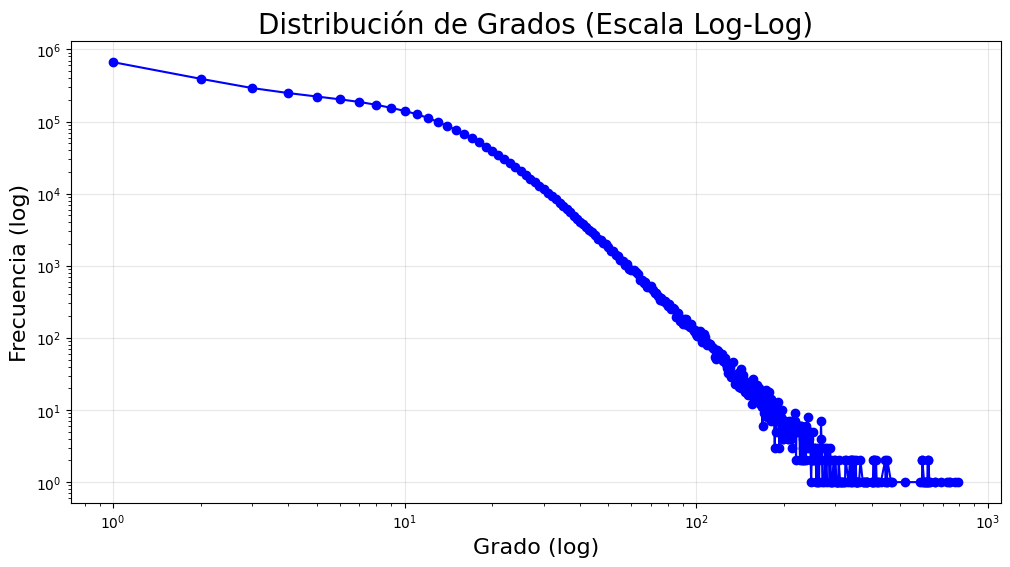

In [8]:
degree_sequence = sorted([d for n, d in G.degree()], reverse=True)
degree_count = np.bincount(degree_sequence)
degree_values = np.arange(len(degree_count))

plt.figure(figsize=(12, 6))
plt.bar(degree_values, degree_count, width=0.80, color="b")
plt.title("Distribución de Grados", fontsize=20)
plt.ylabel("Frecuencia", fontsize=16)
plt.xlabel("Grado", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
plt.loglog(degree_values[degree_count > 0], degree_count[degree_count > 0], 'bo-')
plt.title("Distribución de Grados (Escala Log-Log)", fontsize=20)
plt.ylabel("Frecuencia (log)", fontsize=16)
plt.xlabel("Grado (log)", fontsize=16)
plt.grid(alpha=0.3)
plt.show()


== CLUSTERING Y TRANSITIVIDAD ==
Calculando coeficiente de clustering global...
Transitividad global (fracción de triángulos): 0.026431
Calculando coeficiente de clustering promedio...
Coeficiente de clustering promedio: 0.037831
Calculando distribución de coeficientes de clustering...


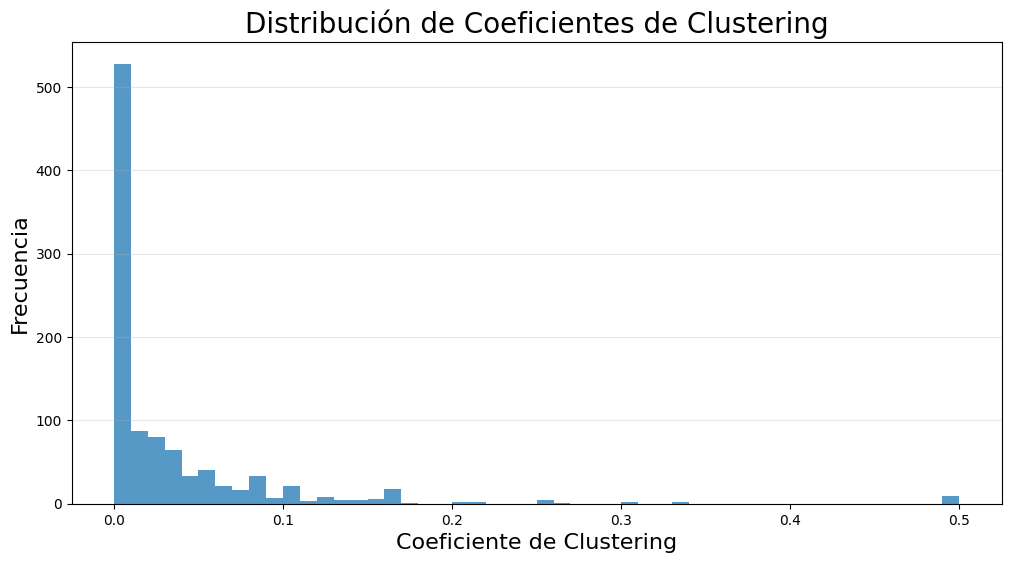

In [9]:
print("\n== CLUSTERING Y TRANSITIVIDAD ==")
print("Calculando coeficiente de clustering global...")
transitivity = nx.transitivity(G)
print(f"Transitividad global (fracción de triángulos): {transitivity:.6f}")

print("Calculando coeficiente de clustering promedio...")
avg_clustering = nx.average_clustering(G)
print(f"Coeficiente de clustering promedio: {avg_clustering:.6f}")

print("Calculando distribución de coeficientes de clustering...")
if G.number_of_nodes() > 5000:
    sample_nodes = np.random.choice(list(G.nodes()), min(1000, G.number_of_nodes()), replace=False)
    clustering_coeffs = nx.clustering(G, nodes=sample_nodes)
else:
    clustering_coeffs = nx.clustering(G)

plt.figure(figsize=(12, 6))
plt.hist(list(clustering_coeffs.values()), bins=50, alpha=0.75)
plt.title("Distribución de Coeficientes de Clustering", fontsize=20)
plt.xlabel("Coeficiente de Clustering", fontsize=16)
plt.ylabel("Frecuencia", fontsize=16)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [10]:
random.seed(42)

largest_weakly_connected_component = max(nx.weakly_connected_components(G), key=len)
largest_weakly_connected_subgraph = G.subgraph(largest_weakly_connected_component)

# Node sampling and path calculation
nodes_list = list(largest_weakly_connected_subgraph.nodes())
sample_size = min(1000, len(nodes_list))
sample_nodes = random.sample(nodes_list, sample_size)

path_lengths = []

for node in sample_nodes:
    lengths = nx.single_source_shortest_path_length(largest_weakly_connected_subgraph, node)
    path_lengths.extend(lengths.values())

average_path_length_sample = np.mean(path_lengths)
print(f"Longitud promedio del camino (usando muestreo): {average_path_length_sample}")


Longitud promedio del camino (usando muestreo): 6.923727719058941


Considerando que es un grafo tan grande y requiere mucho costo computacional, se obtiene un subgrafo para obtener el sistema de recomendación.

In [11]:
def create_subgraph(G, sample_size=50000):
    nodes_list = list(G.nodes())
    random.seed(42)
    sub_nodes = random.sample(nodes_list, min(sample_size, len(nodes_list)))
    return G.subgraph(sub_nodes)

In [12]:
sub_graph = create_subgraph(G)
print("Number of nodes:", sub_graph.number_of_nodes())
print("Number of edges:", sub_graph.number_of_edges())

Number of nodes: 50000
Number of edges: 2867


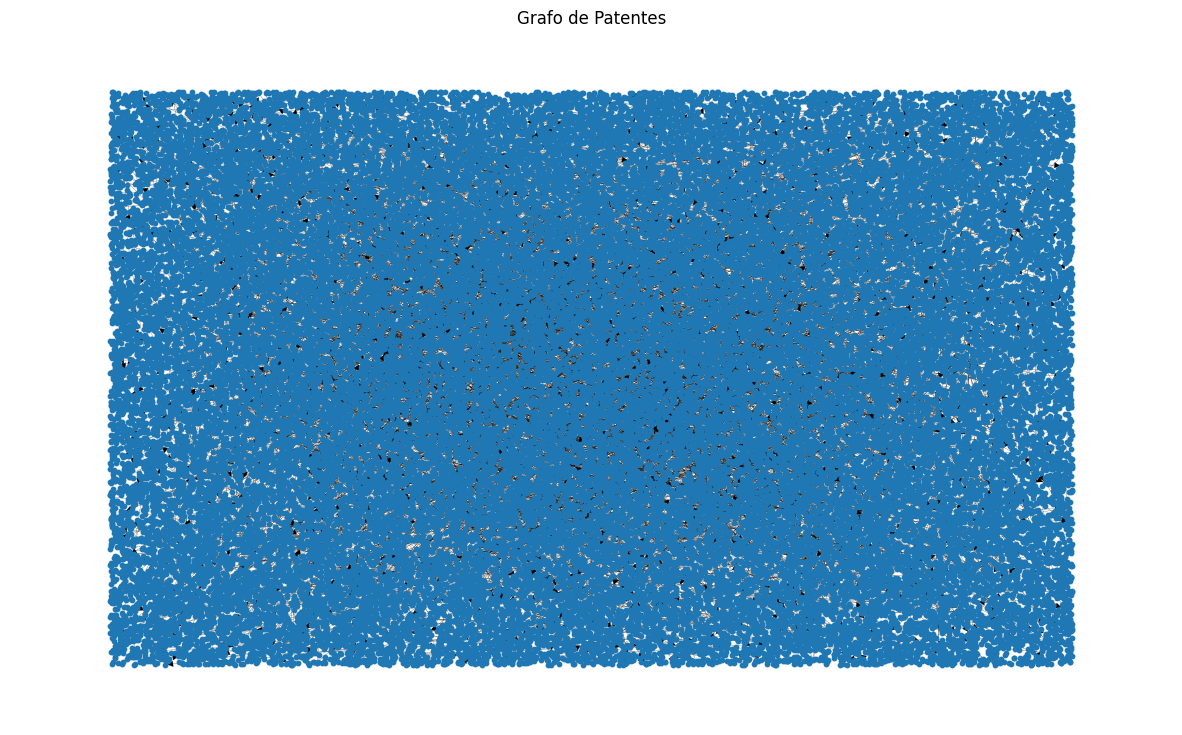

In [13]:
def visualize_graph(G):
    fig, ax = plt.subplots(figsize=(15, 9))
    ax.axis("off")
    plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
    nx.draw_networkx(G, pos=nx.random_layout(G), ax=ax, **plot_options)
    plt.title("Grafo de Patentes")
    plt.show()

visualize_graph(sub_graph)

In [14]:
node2vec = Node2Vec(sub_graph, dimensions=64, walk_length=10, num_walks=100, workers=2)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

Computing transition probabilities:   0%|          | 0/50000 [00:00<?, ?it/s]

In [15]:
model.wv.index_to_key[0]

'4313113'

In [17]:
target_node = '4313113'
similarities = cosine_similarity(
    [model.wv[str(target_node)]],
    [model.wv[str(node)] for node in sub_graph.nodes()]
)

# Create a DataFrame of similarities
similar_patents = pd.DataFrame(
    data={
        'node': list(sub_graph.nodes()),
        'similarity': similarities.flatten()
    }
)

# Get top 10 similar patents
top_similar = similar_patents.sort_values(by='similarity', ascending=False).head(11)[1:]

print(top_similar)

          node  similarity
49217  5371846    0.994609
31388  5717877    0.993249
32621  5196838    0.990362
40676  5873083    0.980793
49461  4586035    0.980176
12066  5012231    0.974999
8931   5659333    0.966627
21836  5431064    0.965458
31856  5850285    0.932867
9068   5790820    0.914222


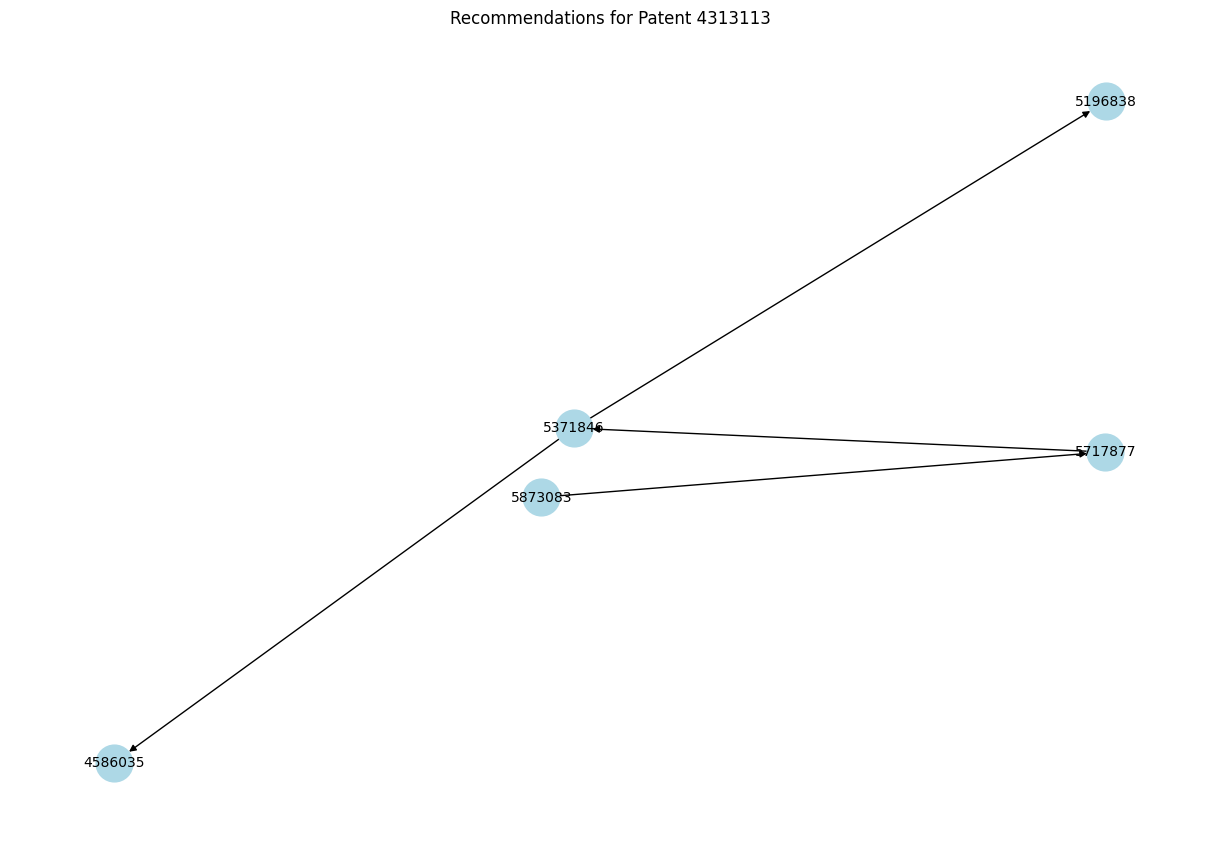

In [18]:
def visualize_recommendations(G, target_node, similar_patents, top_n=10):
    plt.figure(figsize=(12, 8))
    subgraph = G.subgraph([target_node] + list(similar_patents['node'].head(top_n)))

    pos = nx.spring_layout(subgraph, seed=42)
    nx.draw(subgraph, pos, with_labels=True, node_size=700, node_color='lightblue', font_size=10)
    plt.title(f"Recommendations for Patent {target_node}")
    plt.show()

# Visualize top 5 recommendations
visualize_recommendations(sub_graph, target_node, top_similar, top_n=5)